# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 2. Load the Data

In [2]:
data = pd.read_excel("Infrastructure.xlsx")

# 3. Data Information and Initial Cleaning

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20874 entries, 0 to 20873
Data columns (total 4 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Inund Depth obs. (m)                    20874 non-null  float64
 1   Damage Indices (0-4)                    20874 non-null  int64  
 2   Material (RC, Steel, Wood, Masonry)     20874 non-null  object 
 3   Structure (Building or Infrastructure)  20874 non-null  object 
dtypes: float64(1), int64(1), object(2)
memory usage: 652.4+ KB


In [4]:
data.drop(columns=["Structure (Building or Infrastructure)"], inplace=True)

In [5]:
data.head(20)

,Inund Depth obs. (m),Damage Indices (0-4),"Material (RC, Steel, Wood, Masonry)"
0,2.1,2,Masonry
1,1.8,2,Masonry
2,2.2,2,Masonry
3,2.0,2,Wood
4,2.0,2,Wood
5,2.3,2,Masonry
6,1.1,2,Wood
7,1.3,2,Masonry
8,2.0,2,Wood
9,2.1,2,Wood


#  4.Renaming Columns for Clarity


In [6]:
data.rename(columns={
    'Inund Depth obs. (m)': 'Inund Depth',
    'Damage Indices (0-4)': 'Damage Indices',
    'Material (RC, Steel, Wood, Masonry)': 'Material'
}, inplace=True)

# Print the DataFrame with renamed columns
data.head()

,Inund Depth,Damage Indices,Material
0,2.1,2,Masonry
1,1.8,2,Masonry
2,2.2,2,Masonry
3,2.0,2,Wood
4,2.0,2,Wood


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20874 entries, 0 to 20873
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Inund Depth     20874 non-null  float64
 1   Damage Indices  20874 non-null  int64  
 2   Material        20874 non-null  object 
dtypes: float64(1), int64(1), object(1)
memory usage: 489.4+ KB


In [8]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data['Inund Depth'] = scaler.fit_transform(data[['Inund Depth']])  # Original column overwrite ho gaya


# 5. Value Counts and Filtering the Data

In [9]:
data['Inund Depth'].value_counts()

0.081197    615
0.076923    602
0.068376    554
0.085470    542
0.072650    537
           ... 
0.786325      1
0.055983      1
0.017094      1
0.112393      1
0.053419      1
Name: Inund Depth, Length: 296, dtype: int64

In [10]:
data["Damage Indices"].value_counts()

2    7155
4    6891
3    5221
1    1428
0     179
Name: Damage Indices, dtype: int64

In [11]:
data["Damage Indices"].value_counts()

2    7155
4    6891
3    5221
1    1428
0     179
Name: Damage Indices, dtype: int64

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20874 entries, 0 to 20873
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Inund Depth     20874 non-null  float64
 1   Damage Indices  20874 non-null  int64  
 2   Material        20874 non-null  object 
dtypes: float64(1), int64(1), object(1)
memory usage: 489.4+ KB


In [13]:
data.drop(data[(data['Damage Indices'] == 2) | (data['Damage Indices'] == 3) | (data['Damage Indices'] == 4)].index, inplace=True)

In [14]:
data["Damage Indices"].value_counts()

1    1428
0     179
Name: Damage Indices, dtype: int64

In [15]:
data.shape

(1607, 3)

In [16]:
data.duplicated().sum()

1375

In [17]:
data['Inund Depth'].value_counts()

0.047009    119
0.042735    116
0.068376    108
0.055556    107
0.051282    104
           ... 
0.077778      1
0.076068      1
0.062821      1
0.055128      1
0.175214      1
Name: Inund Depth, Length: 105, dtype: int64

# 6. One-Hot Encoding for Categorical Variables

In [18]:
pd.get_dummies(data,columns=["Damage Indices","Material"])

,Inund Depth,Damage Indices_0,Damage Indices_1,Material_Masonry,Material_Reinforced concrete,Material_Steel,Material_Wood
59,0.055556,1,0,0,0,0,1
73,0.081197,1,0,1,0,0,0
233,0.047009,0,1,1,0,0,0
243,0.106838,1,0,1,0,0,0
244,0.106838,1,0,0,0,0,1
...,...,...,...,...,...,...,...
20575,0.045726,0,1,0,0,0,1
20576,0.047009,0,1,0,0,0,1
20855,0.128205,0,1,1,0,0,0
20856,0.128205,0,1,1,0,0,0


In [19]:
data = pd.get_dummies(data,columns=["Damage Indices","Material"],drop_first= False)
data.head()

,Inund Depth,Damage Indices_0,Damage Indices_1,Material_Masonry,Material_Reinforced concrete,Material_Steel,Material_Wood
59,0.055556,1,0,0,0,0,1
73,0.081197,1,0,1,0,0,0
233,0.047009,0,1,1,0,0,0
243,0.106838,1,0,1,0,0,0
244,0.106838,1,0,0,0,0,1


In [20]:
data.shape

(1607, 7)

In [21]:
data.duplicated().sum()

1375

# 7. Define Features and Target Variables

In [22]:
# Define features (X) and target (y)
X = data[['Inund Depth', 'Material_Reinforced concrete', 'Material_Steel', 'Material_Wood']]
y = data[['Damage Indices_0','Damage Indices_1']]

In [23]:
y = np.argmax(y.values, axis=1)

# 8. Split the Data into Training, Validation, and Test Sets

In [24]:
from sklearn.model_selection import train_test_split

# First, split the data into 90% training+validation and 10% testing
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Further split the training+validation set into training (80%) and validation (20%)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=0)



# 9. Initialize and Train the Random Forest Model

In [25]:
# Step 4: Initialize and Train the Random Forest Model
rf = RandomForestClassifier(n_estimators=100, random_state=0)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=0)

# 10. Evaluate the Model on the Test Set

In [26]:
# Step 6: Evaluate on the Test Set
y_test_pred = rf.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.8913043478260869


# 11. Classification Report

In [27]:
# Step 7: Detailed Classification Report
print("Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred))

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.53      0.43      0.48        37
           1       0.93      0.95      0.94       285

    accuracy                           0.89       322
   macro avg       0.73      0.69      0.71       322
weighted avg       0.88      0.89      0.89       322



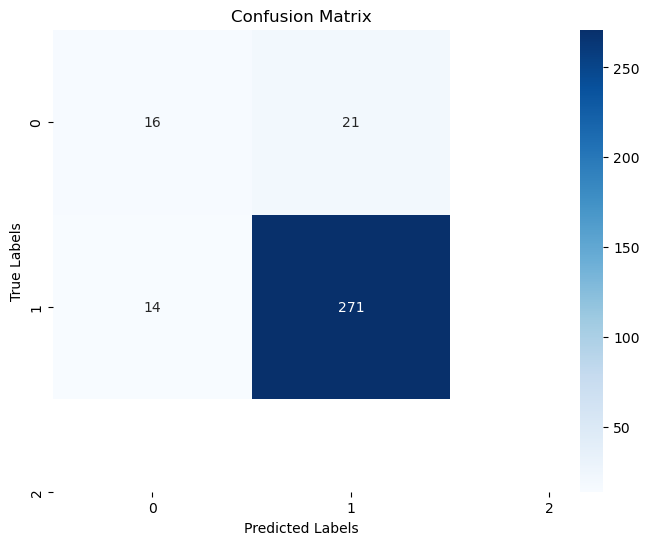

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1, 2], yticklabels=[0, 1, 2])


plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")


plt.show()
